### 24RB1075 小嶋将太郎

### 課題１

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

iris = load_iris()

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
target_names = iris.target_names

### 課題２

In [4]:
# LDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

model1 = LinearDiscriminantAnalysis()
model1.fit(X_train, y_train)
y_pred1 = model1.predict(X_test)
score1 = model1.score(X_test, y_test)
print("LDA accuracy: ", score1)

LDA accuracy:  0.9777777777777777


In [6]:
# ナイーブベイズ
from sklearn.naive_bayes import GaussianNB

model2= GaussianNB()
model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)
score2 = model2.score(X_test, y_test)
print("GaussianNB accuracy:", score2)

GaussianNB accuracy: 1.0


In [7]:
# 線形回帰
from sklearn.linear_model import LinearRegression
model3 = LinearRegression()
model3.fit(X_train, y_train)
y_pred3 = model3.predict(X_test)
score3 = model3.score(X_test, y_test)
print("LinearRegression accuracy:", score3)


LinearRegression accuracy: 0.8998261101639005


### 課題３

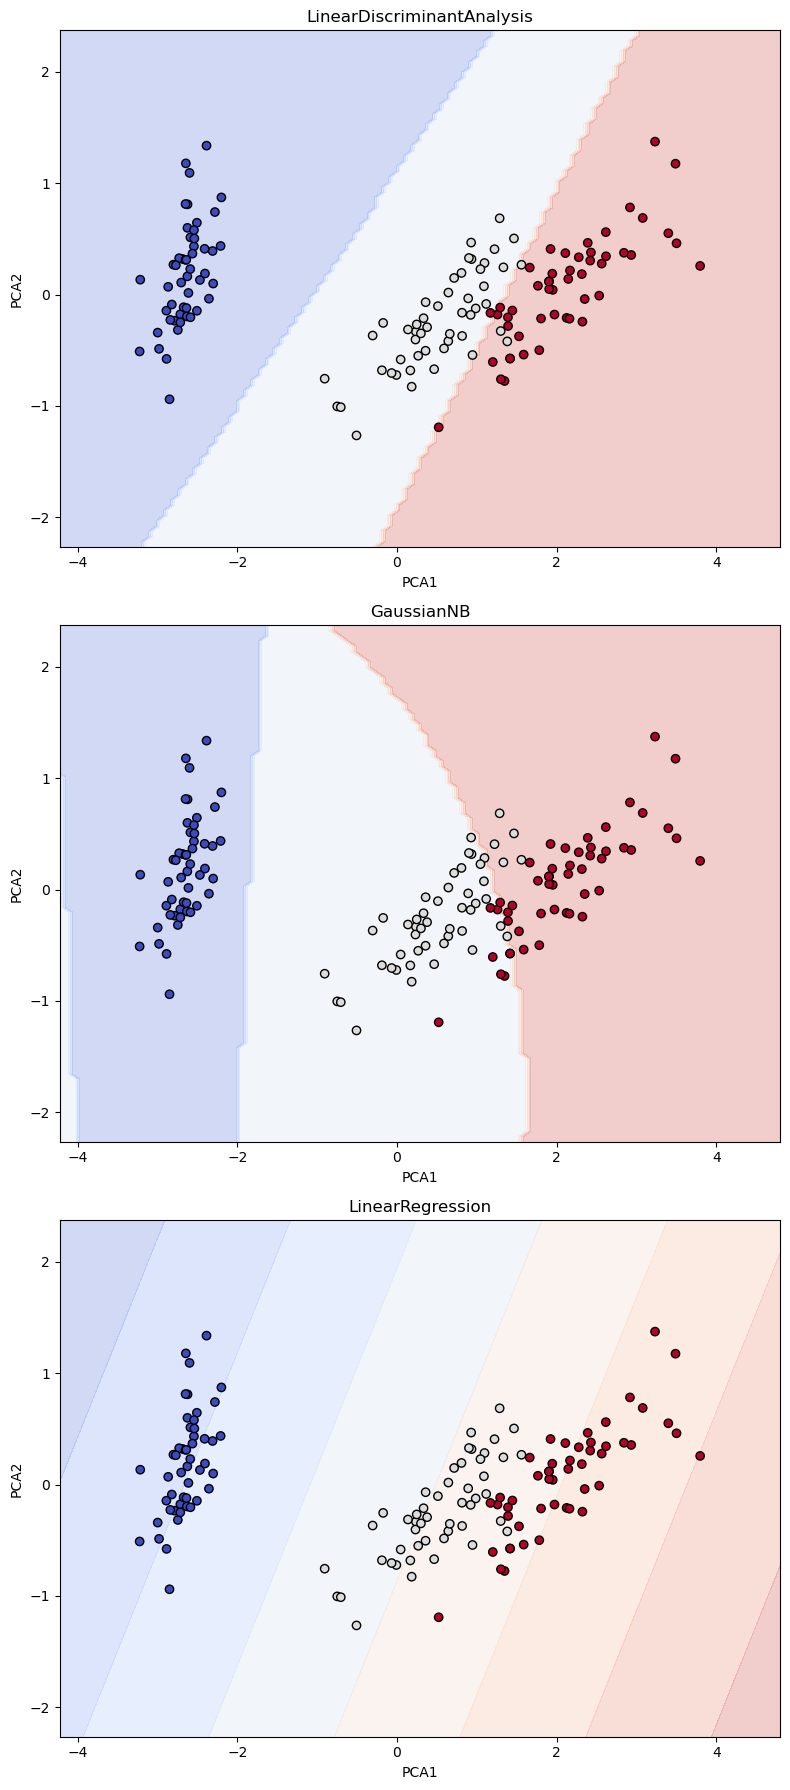

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.inspection import DecisionBoundaryDisplay

# pcaで次元削減
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.3, random_state=0)

models = [model1, model2, model3]

fig,axes = plt.subplots(3, 1, figsize=(8, 18))

for i, model in enumerate(models):
    model.fit(X_train_pca, y_train_pca)

    model_name = type(model).__name__
    ax = axes[i]

    DecisionBoundaryDisplay.from_estimator(model, X_train_pca, alpha=0.25, ax=ax, response_method="predict", cmap = 'coolwarm')

    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y, edgecolor='k', marker='o',cmap='coolwarm')
    ax.set_title(model_name)
    ax.set_xlabel("PCA1")
    ax.set_ylabel("PCA2")
plt.tight_layout()
plt.show()

